# PySpark使用SparkSQL查询数据

In [177]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql.functions import count,when,col,mean,round,udf
from pyspark.sql.types import FloatType
# SparkSession 强制指定字符集为 UTF-8
# 初始化 Spark 时加配置，加一行配置，强制把 executor 日志输出到当前终端：
spark=SparkSession.builder\
    .appName('Spark_sql')\
    .master("local[*]") \
    .config("spark.executor.extraJavaOptions", "-Dlog4j.configuration=file:///dev/null") \
    .config("spark.driver.extraJavaOptions", "-Dlog4j.configuration=file:///dev/null") \
    .getOrCreate()
# Excel 保存的中文 CSV 必须用 encoding='gbk' 
# 你用 Excel / WPS 保存 CSV
# → 默认编码是 GBK（Windows 中文版系统都是 GBK）
df=spark.read.csv('../python基础/data/employee.csv',
                  header=True,
                  inferSchema=True,
                  encoding='utf-8',
                  )
df.show(10)
df.printSchema()
df.count()

+------+----+----+----+----------+----------+----+-------+---------+---------+----------+
|emp_id|姓名| age|性别|department|       job|city| salary|education|work_year|is_married|
+------+----+----+----+----------+----------+----+-------+---------+---------+----------+
|     1|王磊|  28|  男|    技术部|  后端开发|北京|18500.0|     本科|        5|        是|
|     2|刘芳|  32|  女|    产品部|  产品经理|上海|25000.0|     硕士|        7|        是|
|     3|张伟|  24|  男|    运营部|新媒体运营|广州| 9800.0|     大专|        2|        否|
|     4|李娜|NULL|  女|    市场部|  市场专员|深圳|11200.0|     本科|     NULL|        否|
|     5|陈阳|  35|  男|    财务部|  财务主管|杭州|22000.0|     本科|       10|        是|
|     6|赵静|  26|  女|    人事部|        HR|成都|   NULL|     本科|        3|        否|
|     7|吴浩|  29|  男|    技术部|  前端开发|武汉|16000.0|     大专|        4|        否|
|     8|郑敏|  31|  女|    产品部|  交互设计|重庆|   NULL|     硕士|        6|        是|
|     9|钱明|NULL|  男|    运营部|  用户运营|南京|10500.0|     本科|        2|        否|
|    10|孙佳|  27|  女|    市场部|  品牌推广|苏州|13000.0|     本科|  

300

In [178]:
print("===== 每列缺失值统计 =====")
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show(truncate=False)

===== 每列缺失值统计 =====
+------+----+---+----+----------+---+----+------+---------+---------+----------+
|emp_id|姓名|age|性别|department|job|city|salary|education|work_year|is_married|
+------+----+---+----+----------+---+----+------+---------+---------+----------+
|0     |0   |4  |36  |0         |0  |0   |49    |0        |1        |0         |
+------+----+---+----+----------+---+----+------+---------+---------+----------+



In [179]:
# 4. 自动获取所有数值型列
numeric_cols = [f.name for f in df.schema.fields if f.dataType.typeName() in ['integer', 'double', 'long']]

In [180]:
# 5. 对所有数值列用【平均值】填充空值
print("\n===== 开始用平均值填充空值 =====")
for col_name in numeric_cols:
    avg_val = df.select(round(mean(col(col_name)),1)).first()[0]  # 计算该列平均值
    df = df.fillna({col_name: avg_val})   


===== 开始用平均值填充空值 =====


In [181]:
print("\n===== 填充后每列缺失值统计 =====")
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show(truncate=False)


===== 填充后每列缺失值统计 =====
+------+----+---+----+----------+---+----+------+---------+---------+----------+
|emp_id|姓名|age|性别|department|job|city|salary|education|work_year|is_married|
+------+----+---+----+----------+---+----+------+---------+---------+----------+
|0     |0   |0  |36  |0         |0  |0   |0     |0        |0        |0         |
+------+----+---+----+----------+---+----+------+---------+---------+----------+



In [182]:
#注册Dataframe为临时表或者视图
df.createOrReplaceTempView('employee')

In [183]:
#使用spark.sql方法执行sql语句
spark.sql('select * from employee')

DataFrame[emp_id: int, 姓名: string, age: int, 性别: string, department: string, job: string, city: string, salary: double, education: string, work_year: int, is_married: string]

In [184]:
#使用spark.sql方法执行sql语句
spark.sql('select * from employee').show(10)

+------+----+---+----+----------+----------+----+-------+---------+---------+----------+
|emp_id|姓名|age|性别|department|       job|city| salary|education|work_year|is_married|
+------+----+---+----+----------+----------+----+-------+---------+---------+----------+
|     1|王磊| 28|  男|    技术部|  后端开发|北京|18500.0|     本科|        5|        是|
|     2|刘芳| 32|  女|    产品部|  产品经理|上海|25000.0|     硕士|        7|        是|
|     3|张伟| 24|  男|    运营部|新媒体运营|广州| 9800.0|     大专|        2|        否|
|     4|李娜| 29|  女|    市场部|  市场专员|深圳|11200.0|     本科|        5|        否|
|     5|陈阳| 35|  男|    财务部|  财务主管|杭州|22000.0|     本科|       10|        是|
|     6|赵静| 26|  女|    人事部|        HR|成都|16243.0|     本科|        3|        否|
|     7|吴浩| 29|  男|    技术部|  前端开发|武汉|16000.0|     大专|        4|        否|
|     8|郑敏| 31|  女|    产品部|  交互设计|重庆|16243.0|     硕士|        6|        是|
|     9|钱明| 29|  男|    运营部|  用户运营|南京|10500.0|     本科|        2|        否|
|    10|孙佳| 27|  女|    市场部|  品牌推广|苏州|13000.0|     本科|        3|     

In [185]:
#如果列是中文名字,则需要用反引号把列扩起来
spark.sql('select emp_id,`姓名`,age,`性别`,department,job,salary from employee' ).show(10)


+------+----+---+----+----------+----------+-------+
|emp_id|姓名|age|性别|department|       job| salary|
+------+----+---+----+----------+----------+-------+
|     1|王磊| 28|  男|    技术部|  后端开发|18500.0|
|     2|刘芳| 32|  女|    产品部|  产品经理|25000.0|
|     3|张伟| 24|  男|    运营部|新媒体运营| 9800.0|
|     4|李娜| 29|  女|    市场部|  市场专员|11200.0|
|     5|陈阳| 35|  男|    财务部|  财务主管|22000.0|
|     6|赵静| 26|  女|    人事部|        HR|16243.0|
|     7|吴浩| 29|  男|    技术部|  前端开发|16000.0|
|     8|郑敏| 31|  女|    产品部|  交互设计|16243.0|
|     9|钱明| 29|  男|    运营部|  用户运营|10500.0|
|    10|孙佳| 27|  女|    市场部|  品牌推广|13000.0|
+------+----+---+----+----------+----------+-------+
only showing top 10 rows



In [186]:
#执行简单的计算
spark.sql('select emp_id,`姓名`,age,`性别`,department,job,salary*2.1 as `年终奖`from employee').show(15)

+------+----+---+----+----------+----------+-------+
|emp_id|姓名|age|性别|department|       job| 年终奖|
+------+----+---+----+----------+----------+-------+
|     1|王磊| 28|  男|    技术部|  后端开发|38850.0|
|     2|刘芳| 32|  女|    产品部|  产品经理|52500.0|
|     3|张伟| 24|  男|    运营部|新媒体运营|20580.0|
|     4|李娜| 29|  女|    市场部|  市场专员|23520.0|
|     5|陈阳| 35|  男|    财务部|  财务主管|46200.0|
|     6|赵静| 26|  女|    人事部|        HR|34110.3|
|     7|吴浩| 29|  男|    技术部|  前端开发|33600.0|
|     8|郑敏| 31|  女|    产品部|  交互设计|34110.3|
|     9|钱明| 29|  男|    运营部|  用户运营|22050.0|
|    10|孙佳| 27|  女|    市场部|  品牌推广|27300.0|
|    11|冯辉| 33|  男|    技术部|大数据开发|58800.0|
|    12|褚洁| 23|  女|    财务部|      出纳|15750.0|
|    13|卫强| 30|  男|    人事部|  招聘专员|34110.3|
|    14|蒋丽| 34|  女|    技术部|  测试开发|44100.0|
|    15|沈洋| 25|  男|    产品部|  需求分析|29400.0|
+------+----+---+----+----------+----------+-------+
only showing top 15 rows



In [187]:
# 5给sql传递变量
#每个人的绩效奖金
add_count=500


In [188]:
#第一种方法传递变量
spark.sql(f'select emp_id,`姓名`,age,`性别`,department,job,salary as `薪资`,salary*2.1+{add_count} as `年终奖`from employee').show(15)

+------+----+---+----+----------+----------+-------+-------+
|emp_id|姓名|age|性别|department|       job|   薪资| 年终奖|
+------+----+---+----+----------+----------+-------+-------+
|     1|王磊| 28|  男|    技术部|  后端开发|18500.0|39350.0|
|     2|刘芳| 32|  女|    产品部|  产品经理|25000.0|53000.0|
|     3|张伟| 24|  男|    运营部|新媒体运营| 9800.0|21080.0|
|     4|李娜| 29|  女|    市场部|  市场专员|11200.0|24020.0|
|     5|陈阳| 35|  男|    财务部|  财务主管|22000.0|46700.0|
|     6|赵静| 26|  女|    人事部|        HR|16243.0|34610.3|
|     7|吴浩| 29|  男|    技术部|  前端开发|16000.0|34100.0|
|     8|郑敏| 31|  女|    产品部|  交互设计|16243.0|34610.3|
|     9|钱明| 29|  男|    运营部|  用户运营|10500.0|22550.0|
|    10|孙佳| 27|  女|    市场部|  品牌推广|13000.0|27800.0|
|    11|冯辉| 33|  男|    技术部|大数据开发|28000.0|59300.0|
|    12|褚洁| 23|  女|    财务部|      出纳| 7500.0|16250.0|
|    13|卫强| 30|  男|    人事部|  招聘专员|16243.0|34610.3|
|    14|蒋丽| 34|  女|    技术部|  测试开发|21000.0|44600.0|
|    15|沈洋| 25|  男|    产品部|  需求分析|14000.0|29900.0|
+------+----+---+----+----------+----------+-------+-----

In [189]:
#第二种方法传递变量占位符方法
spark.sql('select emp_id,`姓名`,age,`性别`,department,job,salary as `薪资`,salary*2.1+{add_count} as `年终奖`from employee',add_count=add_count).show(15)

+------+----+---+----+----------+----------+-------+-------+
|emp_id|姓名|age|性别|department|       job|   薪资| 年终奖|
+------+----+---+----+----------+----------+-------+-------+
|     1|王磊| 28|  男|    技术部|  后端开发|18500.0|39350.0|
|     2|刘芳| 32|  女|    产品部|  产品经理|25000.0|53000.0|
|     3|张伟| 24|  男|    运营部|新媒体运营| 9800.0|21080.0|
|     4|李娜| 29|  女|    市场部|  市场专员|11200.0|24020.0|
|     5|陈阳| 35|  男|    财务部|  财务主管|22000.0|46700.0|
|     6|赵静| 26|  女|    人事部|        HR|16243.0|34610.3|
|     7|吴浩| 29|  男|    技术部|  前端开发|16000.0|34100.0|
|     8|郑敏| 31|  女|    产品部|  交互设计|16243.0|34610.3|
|     9|钱明| 29|  男|    运营部|  用户运营|10500.0|22550.0|
|    10|孙佳| 27|  女|    市场部|  品牌推广|13000.0|27800.0|
|    11|冯辉| 33|  男|    技术部|大数据开发|28000.0|59300.0|
|    12|褚洁| 23|  女|    财务部|      出纳| 7500.0|16250.0|
|    13|卫强| 30|  男|    人事部|  招聘专员|16243.0|34610.3|
|    14|蒋丽| 34|  女|    技术部|  测试开发|21000.0|44600.0|
|    15|沈洋| 25|  男|    产品部|  需求分析|14000.0|29900.0|
+------+----+---+----+----------+----------+-------+-----

In [190]:
#进行复杂的聚合统计
# 查找每个部门的最高薪资最低薪资平均薪资
sql=''' 
    select department,
    count(*) as `人数`,
    max(salary) as `最高薪资`,
    min(salary) as `最低薪资`,
    round(avg(salary),2) as `平均薪资`
    from employee
    group by department
'''

In [191]:
spark.sql(sql).show(10)

+----------+----+--------+--------+--------+
|department|人数|最高薪资|最低薪资|平均薪资|
+----------+----+--------+--------+--------+
|    技术部|  91| 38000.0| 11600.0|21067.52|
|    财务部|  40| 29000.0|  4100.0| 10935.0|
|    人事部|  26| 16243.0|  7200.0|13505.04|
|    市场部|  49| 45000.0|  8500.0|17380.47|
|    产品部|  41| 25000.0|  8200.0|15805.63|
|    运营部|  53| 28000.0|  9100.0|12595.43|
+----------+----+--------+--------+--------+



In [192]:
# 7:在Sparksql中自定义函数
def compute_bonus(salary):
    '''计算2025年年终奖'''
    return salary*0.5
#注册自定义函数
spark.udf.register('compute_bonus',compute_bonus,FloatType())


<function __main__.compute_bonus(salary)>

In [193]:
spark.sql('select emp_id,`姓名`,age,`性别`,department,job,salary,compute_bonus(salary) as `2025年年终奖` from employee').show(5)

+------+----+---+----+----------+----------+-------+------------+
|emp_id|姓名|age|性别|department|       job| salary|2025年年终奖|
+------+----+---+----+----------+----------+-------+------------+
|     1|王磊| 28|  男|    技术部|  后端开发|18500.0|      9250.0|
|     2|刘芳| 32|  女|    产品部|  产品经理|25000.0|     12500.0|
|     3|张伟| 24|  男|    运营部|新媒体运营| 9800.0|      4900.0|
|     4|李娜| 29|  女|    市场部|  市场专员|11200.0|      5600.0|
|     5|陈阳| 35|  男|    财务部|  财务主管|22000.0|     11000.0|
+------+----+---+----+----------+----------+-------+------------+
only showing top 5 rows



# PySpark怎样使用for循环处理数据

In [194]:
df.show(3)

+------+----+---+----+----------+----------+----+-------+---------+---------+----------+
|emp_id|姓名|age|性别|department|       job|city| salary|education|work_year|is_married|
+------+----+---+----+----------+----------+----+-------+---------+---------+----------+
|     1|王磊| 28|  男|    技术部|  后端开发|北京|18500.0|     本科|        5|        是|
|     2|刘芳| 32|  女|    产品部|  产品经理|上海|25000.0|     硕士|        7|        是|
|     3|张伟| 24|  男|    运营部|新媒体运营|广州| 9800.0|     大专|        2|        否|
+------+----+---+----+----------+----------+----+-------+---------+---------+----------+
only showing top 3 rows




## 2：使用collect方法将数据收集到本地
注意:一般情况下，数据是存储在集群上的，collect方法将数据收集到本地，通常不是好的做法。因为这样做可能会导致分布式数据集的大量数据被收集到单个机器上，比如200TB数据，从而导致性能下降或内存溢出。然而，如果数据集不大，可以通过将DataFrame转换为本地Python对象来进行遍历。这种方法应该谨慎使用，主要用于调试目的或处理小规模数据。

In [195]:
#collect方法是返回一个List<Row>格式，每个元素是一个Row,当做字典使用
data=df.collect()

In [196]:
type(data)

list

In [197]:
print('查看前3行数据:')
data[:3]

查看前3行数据:


[Row(emp_id=1, 姓名='王磊', age=28, 性别='男', department='技术部', job='后端开发', city='北京', salary=18500.0, education='本科', work_year=5, is_married='是'),
 Row(emp_id=2, 姓名='刘芳', age=32, 性别='女', department='产品部', job='产品经理', city='上海', salary=25000.0, education='硕士', work_year=7, is_married='是'),
 Row(emp_id=3, 姓名='张伟', age=24, 性别='男', department='运营部', job='新媒体运营', city='广州', salary=9800.0, education='大专', work_year=2, is_married='否')]

In [198]:
#for循环
for row in data[:5]:
    print(row['emp_id'],row['姓名'],row['salary'])

1 王磊 18500.0
2 刘芳 25000.0
3 张伟 9800.0
4 李娜 11200.0
5 陈阳 22000.0


## 3：转换成Pandas的DataFrame到本地做循环
这个办法和collect()相同,也会把数据拉取到本地,数据很大的时候不要用

In [199]:
pandas_df=df.toPandas()
type(pandas_df)

pandas.core.frame.DataFrame

In [200]:
#用Pandas的方法可以访问数据列表,查看前5行数据
pandas_df.head()

,emp_id,姓名,age,性别,department,job,city,salary,education,work_year,is_married
0,1,王磊,28,男,技术部,后端开发,北京,18500.0,本科,5,是
1,2,刘芳,32,女,产品部,产品经理,上海,25000.0,硕士,7,是
2,3,张伟,24,男,运营部,新媒体运营,广州,9800.0,大专,2,否
3,4,李娜,29,女,市场部,市场专员,深圳,11200.0,本科,5,否
4,5,陈阳,35,男,财务部,财务主管,杭州,22000.0,本科,10,是


In [201]:
# for循环pandas_df
for idx,row in pandas_df.head(3).iterrows():   #取前3行,按行遍历
    print(row['emp_id'],row['姓名'],row['salary'])


1 王磊 18500.0
2 刘芳 25000.0
3 张伟 9800.0


## 4:使用foreach直接在集群上遍历
在PySpark中，foreach函数是一个操作，用于对DataFrame或RDD中的每个元素执行特定的操作。
foreach()在每个集群的节点上独立执行。
例如:如果调用print()函数，输出不会显示在你启动作业的控制台上，而是在集群中各个节点的stdout日志中。

In [202]:
#使用foreach进行操作,参数是Row
def print_row(row):
    print(row['emp_id'],row['姓名'],row['salary'])
# 不会看到输出结果,因为输出是在集群节点执行的,如果是在本地,那么就是在后台进程
df.foreach(print_row)

## 5:使用foreachPartition对每个分区遍历
foreachPartition和foreach的区别
与foreach()类似，foreachPartition()也是一个动作操作，
但它提供了在每个分区的基础上执行操作的能力，而不是单个元素。
这意味着指定的函数将对每个分区中的所有元素一次性调用，而不是对每个元素逐一调用。

In [203]:
def process_partition(partition):
    print('#'*50)
    for row in partition:
        print(row['emp_id'],row['姓名'],row['salary'])
    print('#'*50)
df.repartition(10).foreachPartition(process_partition)

# PySpark的字符串处理函数
## 1：读取数据

In [204]:
#读取英文名字的csv文件
df_1=spark.read.csv('../python基础/data/english_person.csv',
                  header=True,
                  inferSchema=True,
                  encoding='utf-8',
                  )
df_1.printSchema()
df_1.count()
df_1.show(3)

root
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- birthday: date (nullable = true)
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- city: string (nullable = true)
 |-- address: string (nullable = true)
 |-- email: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- salary: integer (nullable = true)

+----------+---------+------+----------+---+-----------------+--------+-------------+--------------------+------------+------+
|first_name|last_name|gender|  birthday|age|              job|    city|      address|               email|       phone|salary|
+----------+---------+------+----------+---+-----------------+--------+-------------+--------------------+------------+------+
|     James|    Smith|  Male|1985-03-12| 39|Software Engineer|New York| 123 Park Ave|james.smith@email...|212-555-1234| 98000|
|     Emily|  Johnson|Female|1992-07-24| 32|           Doctor|  Bost

## 2:拼接字符串
concat():合并两个或多个列为一个列，没有分隔符
concat_ws():合并多个列为一个列，并在每个元素之间添加分隔符。
format_string():按照指定格式模版来格式化字符串，%s是字符串，%d是数字。

In [205]:
from pyspark.sql.functions import concat,concat_ws,format_string
df_1.select(
    'first_name',
    'last_name',
    'age',
    concat(df_1['first_name'],df_1['last_name']).alias('concat_result'),
    concat_ws('#',df_1['first_name'],df_1['last_name']).alias('concat_ws_result'),
    format_string('姓%s名%s年龄%d',df_1['first_name'],df_1['last_name'],df_1['age']).alias('format_string_result')
).show(5,truncate=False)

+-----------+---------+---+----------------+-----------------+--------------------------+
|first_name |last_name|age|concat_result   |concat_ws_result |format_string_result      |
+-----------+---------+---+----------------+-----------------+--------------------------+
|James      |Smith    |39 |JamesSmith      |James#Smith      |姓James名Smith年龄39      |
|Emily      |Johnson  |32 |EmilyJohnson    |Emily#Johnson    |姓Emily名Johnson年龄32    |
|Michael    |Williams |46 |MichaelWilliams |Michael#Williams |姓Michael名Williams年龄46 |
|Jessica    |Brown    |29 |JessicaBrown    |Jessica#Brown    |姓Jessica名Brown年龄29    |
|Christopher|Jones    |41 |ChristopherJones|Christopher#Jones|姓Christopher名Jones年龄41|
+-----------+---------+---+----------------+-----------------+--------------------------+
only showing top 5 rows



## 3:字符串的长度和转换大小写
length():返回字符串的长度。
lower()或upper():将字符串转换为全部小写或大写。

In [206]:
from pyspark.sql.functions import length,lower,upper
df_1.select(
    'first_name',
    length(df_1['first_name']).alias('length_result'),
    lower(df_1['first_name']).alias('lower_result'),
    upper(df_1['first_name']).alias('upper_result')  
).show(5,truncate=False)

+-----------+-------------+------------+------------+
|first_name |length_result|lower_result|upper_result|
+-----------+-------------+------------+------------+
|James      |5            |james       |JAMES       |
|Emily      |5            |emily       |EMILY       |
|Michael    |7            |michael     |MICHAEL     |
|Jessica    |7            |jessica     |JESSICA     |
|Christopher|11           |christopher |CHRISTOPHER |
+-----------+-------------+------------+------------+
only showing top 5 rows



## 4:lit函数的使用
在PySpark中，lit 函数是一个非常有用的工具，它主要用于将一个常量值添加到DataFrame的计算中。
这个函数可以生成一个Column类型的对象，其中包含了你指定的常量值。
使用lit函数可以让你在 DataFrame的转换和查询操作中引入固定的值。

In [207]:
from pyspark.sql.functions import lit
#例如给数据添加新列,是一样的内容
# 添加一个nationality的列,值是USA
df_1.withColumn('nationality',lit('USA')).show(5)

+-----------+---------+------+----------+---+-----------------+-----------+--------------+--------------------+------------+------+-----------+
| first_name|last_name|gender|  birthday|age|              job|       city|       address|               email|       phone|salary|nationality|
+-----------+---------+------+----------+---+-----------------+-----------+--------------+--------------------+------------+------+-----------+
|      James|    Smith|  Male|1985-03-12| 39|Software Engineer|   New York|  123 Park Ave|james.smith@email...|212-555-1234| 98000|        USA|
|      Emily|  Johnson|Female|1992-07-24| 32|           Doctor|     Boston| 45 Oak Street|emily.johnson@ema...|617-555-5678|132000|        USA|
|    Michael| Williams|  Male|1978-11-05| 46|          Teacher|    Chicago| 78 Lake Drive| michael.w@email.com|312-555-9012| 65000|        USA|
|    Jessica|    Brown|Female|1995-01-18| 29|            Nurse|Los Angeles|33 Sunset Blvd| jessica.b@email.com|310-555-3456| 78000|     

In [208]:
df_1.withColumn('nationality',lit('USA')).printSchema()

root
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- birthday: date (nullable = true)
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- city: string (nullable = true)
 |-- address: string (nullable = true)
 |-- email: string (nullable = true)
 |-- phone: string (nullable = true)
 |-- salary: integer (nullable = true)
 |-- nationality: string (nullable = false)



## 5:去除空格
ltrim(),rtrim(),trim():去除字符串左侧、右侧或两侧的空格。

In [209]:
from pyspark.sql.functions import ltrim,rtrim,trim,col
#造假数据,给字符串前后加上空格
df_1_new=df_1.withColumn('first_name_new',concat(lit(' '),df_1['first_name'],lit(' ')))
df_1_new.show(5)


+-----------+---------+------+----------+---+-----------------+-----------+--------------+--------------------+------------+------+--------------+
| first_name|last_name|gender|  birthday|age|              job|       city|       address|               email|       phone|salary|first_name_new|
+-----------+---------+------+----------+---+-----------------+-----------+--------------+--------------------+------------+------+--------------+
|      James|    Smith|  Male|1985-03-12| 39|Software Engineer|   New York|  123 Park Ave|james.smith@email...|212-555-1234| 98000|        James |
|      Emily|  Johnson|Female|1992-07-24| 32|           Doctor|     Boston| 45 Oak Street|emily.johnson@ema...|617-555-5678|132000|        Emily |
|    Michael| Williams|  Male|1978-11-05| 46|          Teacher|    Chicago| 78 Lake Drive| michael.w@email.com|312-555-9012| 65000|      Michael |
|    Jessica|    Brown|Female|1995-01-18| 29|            Nurse|Los Angeles|33 Sunset Blvd| jessica.b@email.com|310-555

In [210]:
df_1_new.select(
    'first_name_new',
    format_string('#%s#',col('first_name_new')).alias('source'), #为了能看出来两边的空格,用%s给前后填充#号
    format_string('#%s#',ltrim(col('first_name_new'))).alias('ltrim_source'),
    format_string('#%s#',rtrim(col('first_name_new'))).alias('rtrim_source'),
    format_string('#%s#',trim(col('first_name_new'))).alias('trim_source')
).show(10)

+--------------+---------------+--------------+--------------+-------------+
|first_name_new|         source|  ltrim_source|  rtrim_source|  trim_source|
+--------------+---------------+--------------+--------------+-------------+
|        James |      # James #|      #James #|      # James#|      #James#|
|        Emily |      # Emily #|      #Emily #|      # Emily#|      #Emily#|
|      Michael |    # Michael #|    #Michael #|    # Michael#|    #Michael#|
|      Jessica |    # Jessica #|    #Jessica #|    # Jessica#|    #Jessica#|
|  Christopher |# Christopher #|#Christopher #|# Christopher#|#Christopher#|
|       Ashley |     # Ashley #|     #Ashley #|     # Ashley#|     #Ashley#|
|        David |      # David #|      #David #|      # David#|      #David#|
|        Sarah |      # Sarah #|      #Sarah #|      # Sarah#|      #Sarah#|
|       Daniel |     # Daniel #|     #Daniel #|     # Daniel#|     #Daniel#|
|     Jennifer |   # Jennifer #|   #Jennifer #|   # Jennifer#|   #Jennifer#|

## 6：正则提取
regexp_extract():使用正则表达式提取匹配的部分

In [211]:
df_1.show(3)

+----------+---------+------+----------+---+-----------------+--------+-------------+--------------------+------------+------+
|first_name|last_name|gender|  birthday|age|              job|    city|      address|               email|       phone|salary|
+----------+---------+------+----------+---+-----------------+--------+-------------+--------------------+------------+------+
|     James|    Smith|  Male|1985-03-12| 39|Software Engineer|New York| 123 Park Ave|james.smith@email...|212-555-1234| 98000|
|     Emily|  Johnson|Female|1992-07-24| 32|           Doctor|  Boston|45 Oak Street|emily.johnson@ema...|617-555-5678|132000|
|   Michael| Williams|  Male|1978-11-05| 46|          Teacher| Chicago|78 Lake Drive| michael.w@email.com|312-555-9012| 65000|
+----------+---------+------+----------+---+-----------------+--------+-------------+--------------------+------------+------+
only showing top 3 rows



In [212]:
from pyspark.sql.functions import regexp_extract
df_1.select(
    'birthday',
    #第二个参数是一个正则表达式，为了匹配2024-04-30，加括号是为了捕获
    #第三个参数1指定返回第一个捕获组的内容，即匹配到的用户名部分，默认从1开始
    regexp_extract(df_1['birthday'],r'\d+-(\d+)-\d+',1).alias('month')
).show(5)

+----------+-----+
|  birthday|month|
+----------+-----+
|1985-03-12|   03|
|1992-07-24|   07|
|1978-11-05|   11|
|1995-01-18|   01|
|1983-09-30|   09|
+----------+-----+
only showing top 5 rows



## 7:正则字符串替换
regexp_relpace函数用于使用正则表达式替换字符串中的文本


In [213]:
from pyspark.sql.functions import regexp_replace
#造假数据格式化一个字符串
df_2_new=df_1.withColumn('pet_name',format_string('小%s,大%s',df_1['first_name'],df_1['last_name']))
df_2_new.show(5)

+-----------+---------+------+----------+---+-----------------+-----------+--------------+--------------------+------------+------+---------------------+
| first_name|last_name|gender|  birthday|age|              job|       city|       address|               email|       phone|salary|             pet_name|
+-----------+---------+------+----------+---+-----------------+-----------+--------------+--------------------+------------+------+---------------------+
|      James|    Smith|  Male|1985-03-12| 39|Software Engineer|   New York|  123 Park Ave|james.smith@email...|212-555-1234| 98000|      小James,大Smith|
|      Emily|  Johnson|Female|1992-07-24| 32|           Doctor|     Boston| 45 Oak Street|emily.johnson@ema...|617-555-5678|132000|    小Emily,大Johnson|
|    Michael| Williams|  Male|1978-11-05| 46|          Teacher|    Chicago| 78 Lake Drive| michael.w@email.com|312-555-9012| 65000| 小Michael,大Williams|
|    Jessica|    Brown|Female|1995-01-18| 29|            Nurse|Los Angeles|33 Suns

In [214]:
#用正则表达式替换掉新列pet_name的汉字，逗号，空格
# regexp_replace(df_new_2['pet_name'],r'小|大|,| ','')
# 对pet_name列进行正则处理,把pet_name列中出现小或者大或者逗号或者空格的。替换为空
df_2_new.withColumn('clean_name',regexp_replace(df_2_new['pet_name'],r'小|大|,| ','')).show(5)

+-----------+---------+------+----------+---+-----------------+-----------+--------------+--------------------+------------+------+---------------------+----------------+
| first_name|last_name|gender|  birthday|age|              job|       city|       address|               email|       phone|salary|             pet_name|      clean_name|
+-----------+---------+------+----------+---+-----------------+-----------+--------------+--------------------+------------+------+---------------------+----------------+
|      James|    Smith|  Male|1985-03-12| 39|Software Engineer|   New York|  123 Park Ave|james.smith@email...|212-555-1234| 98000|      小James,大Smith|      JamesSmith|
|      Emily|  Johnson|Female|1992-07-24| 32|           Doctor|     Boston| 45 Oak Street|emily.johnson@ema...|617-555-5678|132000|    小Emily,大Johnson|    EmilyJohnson|
|    Michael| Williams|  Male|1978-11-05| 46|          Teacher|    Chicago| 78 Lake Drive| michael.w@email.com|312-555-9012| 65000| 小Michael,大William

## 8：提取字符串的子串
substring():提取字符串中的子串。
参数: substring(str: 'ColumnOrName', pos: int, len: int)

In [215]:
from pyspark.sql.functions import substring
df_1.select(  
    'first_name',
    'birthday',
    #提取年份，第一个参数是开始位置，第二个参数是截取的长度
    substring(df_1['birthday'],0,4).alias('year'),
    substring(df_1['birthday'],6,2).alias('month'),
    substring(df_1['birthday'],9,2).alias('day'),

).show(5)

+-----------+----------+----+-----+---+
| first_name|  birthday|year|month|day|
+-----------+----------+----+-----+---+
|      James|1985-03-12|1985|   03| 12|
|      Emily|1992-07-24|1992|   07| 24|
|    Michael|1978-11-05|1978|   11| 05|
|    Jessica|1995-01-18|1995|   01| 18|
|Christopher|1983-09-30|1983|   09| 30|
+-----------+----------+----+-----+---+
only showing top 5 rows



## 9:字符串拆分
split():根据分隔符拆分字符串为数组

In [216]:
from pyspark.sql.functions import split
df_3_new=df_1.select(
    'birthday',
    split(df_1['birthday'],'-').alias('split') 
)

In [217]:
df_3_new.show(3)

+----------+--------------+
|  birthday|         split|
+----------+--------------+
|1985-03-12|[1985, 03, 12]|
|1992-07-24|[1992, 07, 24]|
|1978-11-05|[1978, 11, 05]|
+----------+--------------+
only showing top 3 rows



In [218]:
df_3_new.printSchema()

root
 |-- birthday: date (nullable = true)
 |-- split: array (nullable = true)
 |    |-- element: string (containsNull = false)



对于array类型的几个操作

In [219]:
from pyspark.sql.functions import size
df_3_new.select(
      'birthday',
      'split',
      df_3_new['split'].getItem(0).alias('year'),
      df_3_new['split'].getItem(1).alias('month'),
      df_3_new['split'].getItem(2).alias('day'),
      size(df_3_new['split']).alias('size')
).show(5)

+----------+--------------+----+-----+---+----+
|  birthday|         split|year|month|day|size|
+----------+--------------+----+-----+---+----+
|1985-03-12|[1985, 03, 12]|1985|   03| 12|   3|
|1992-07-24|[1992, 07, 24]|1992|   07| 24|   3|
|1978-11-05|[1978, 11, 05]|1978|   11| 05|   3|
|1995-01-18|[1995, 01, 18]|1995|   01| 18|   3|
|1983-09-30|[1983, 09, 30]|1983|   09| 30|   3|
+----------+--------------+----+-----+---+----+
only showing top 5 rows



# PySpark怎样拆分数据和保存文件

In [220]:
# 读取员工表的数据
df.show(5)

+------+----+---+----+----------+----------+----+-------+---------+---------+----------+
|emp_id|姓名|age|性别|department|       job|city| salary|education|work_year|is_married|
+------+----+---+----+----------+----------+----+-------+---------+---------+----------+
|     1|王磊| 28|  男|    技术部|  后端开发|北京|18500.0|     本科|        5|        是|
|     2|刘芳| 32|  女|    产品部|  产品经理|上海|25000.0|     硕士|        7|        是|
|     3|张伟| 24|  男|    运营部|新媒体运营|广州| 9800.0|     大专|        2|        否|
|     4|李娜| 29|  女|    市场部|  市场专员|深圳|11200.0|     本科|        5|        否|
|     5|陈阳| 35|  男|    财务部|  财务主管|杭州|22000.0|     本科|       10|        是|
+------+----+---+----+----------+----------+----+-------+---------+---------+----------+
only showing top 5 rows



In [221]:
#统计员工表有多少行
df.count()

300

## 获取不同部门的名字

In [222]:
df.select('department').distinct().show()

+----------+
|department|
+----------+
|    技术部|
|    财务部|
|    人事部|
|    市场部|
|    产品部|
|    运营部|
+----------+



## 3、怎样将查询的数据变成Python列表?
在PySpark中，colectQ函数用于将分布式数据集中的所有元素以列表的形式返回到驱动程序(通常是你的本地机器或主节点)使用collect()时注意事项:
内存限制:collect0会将所有数据拉取到单个节点的内存中，因此在处理大规模数据集时可能会导致内存溢出或性能瓶颈。
效率问题:在分布式环境中，将大量数据移动到单个节点通常效率低下，并可能成为处理瓶颈。
·适用场景:推荐仅在数据集较小或者确实需要将全部数据聚集到一个节点进行处理时使用collect()

In [223]:
rows=df.select('department').distinct().collect()
rows

[Row(department='技术部'),
 Row(department='财务部'),
 Row(department='人事部'),
 Row(department='市场部'),
 Row(department='产品部'),
 Row(department='运营部')]

In [224]:
for row in rows:
    print(row['department'])

技术部
财务部
人事部
市场部
产品部
运营部


## 查询每个部门的数据,存入到CSV文件

In [225]:
# 先把所有部门名拉到本地，再循环
dept_list = [row['department'] for row in rows]
for dept_name  in dept_list:
    print('保存部门数据:',dept_name)
    #筛选出这个部门的数据
    df_dept=df[df['department']==dept_name]
    #存储文件
    df_dept.write.mode('overwrite')\
            .format('csv')\
            .option('header',True)\
            .save(f'../python基础/data/员工表不同部门的数据/{dept_name}')


保存部门数据: 技术部
保存部门数据: 财务部
保存部门数据: 人事部
保存部门数据: 市场部
保存部门数据: 产品部
保存部门数据: 运营部


## 5、查询每个部门的数据，存入到csv文件
在PySpark中，repartition函数的主要作用是重新分区。
重新分区可以用来调整 DataFrame的分区数目。
具体来说，repartition可以增加或减少分区数，以便更好地控制并行计算的粒度。
加了5个分区,文件分5份保存
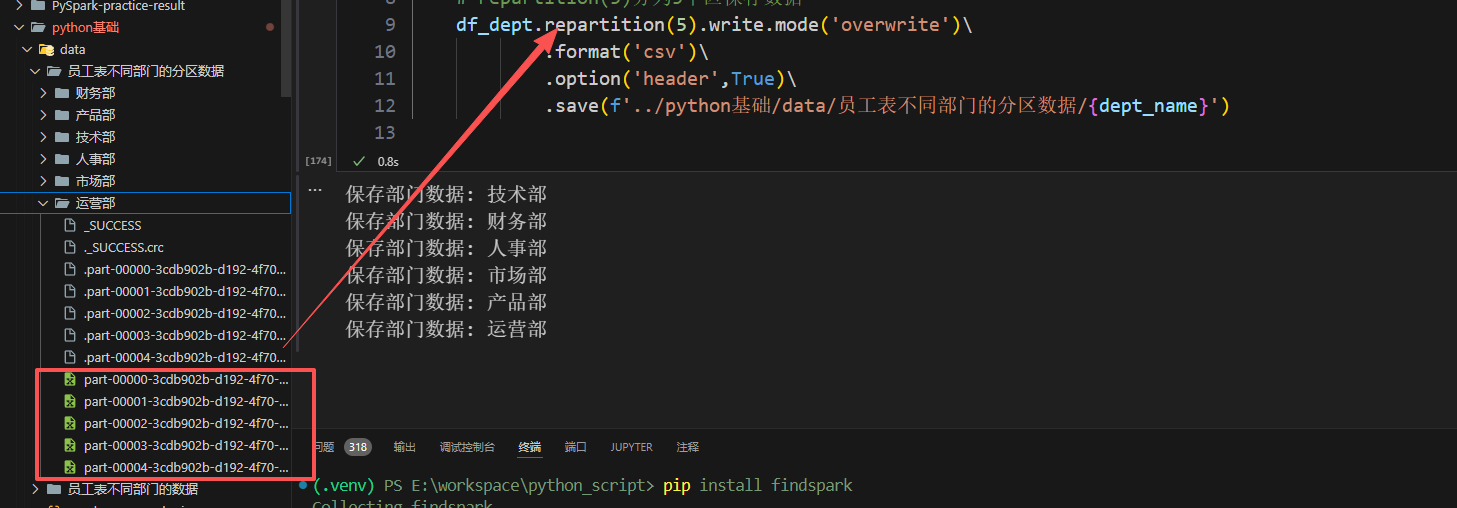

In [226]:
# 先把所有部门名拉到本地，再循环
dept_list = [row['department'] for row in rows]
for dept_name  in dept_list:
    print('保存部门数据:',dept_name)
    #筛选出这个部门的数据
    df_dept=df[df['department']==dept_name]
    #存储文件
    # repartition(5)分为5个区保存数据
    df_dept.repartition(5).write.mode('overwrite')\
            .format('csv')\
            .option('header',True)\
            .save(f'../python基础/data/员工表不同部门的分区数据/{dept_name}')


保存部门数据: 技术部
保存部门数据: 财务部
保存部门数据: 人事部
保存部门数据: 市场部
保存部门数据: 产品部
保存部门数据: 运营部


# PySpark实现分组group数据统计


In [227]:
df.show(5)

+------+----+---+----+----------+----------+----+-------+---------+---------+----------+
|emp_id|姓名|age|性别|department|       job|city| salary|education|work_year|is_married|
+------+----+---+----+----------+----------+----+-------+---------+---------+----------+
|     1|王磊| 28|  男|    技术部|  后端开发|北京|18500.0|     本科|        5|        是|
|     2|刘芳| 32|  女|    产品部|  产品经理|上海|25000.0|     硕士|        7|        是|
|     3|张伟| 24|  男|    运营部|新媒体运营|广州| 9800.0|     大专|        2|        否|
|     4|李娜| 29|  女|    市场部|  市场专员|深圳|11200.0|     本科|        5|        否|
|     5|陈阳| 35|  男|    财务部|  财务主管|杭州|22000.0|     本科|       10|        是|
+------+----+---+----+----------+----------+----+-------+---------+---------+----------+
only showing top 5 rows



## 2：每个部门的聚合统计

In [231]:
from  pyspark.sql.functions import max,min,avg,count
df.groupBy('department').agg(
    max('salary').alias('最高薪资'),
    min('salary').alias('最低薪资'),
    avg('salary').alias('平均薪资'),
    count('*').alias('人数'),
).show(5)

+----------+--------+--------+------------------+----+
|department|最高薪资|最低薪资|          平均薪资|人数|
+----------+--------+--------+------------------+----+
|    技术部| 38000.0| 11600.0|21067.516483516483|  91|
|    财务部| 29000.0|  4100.0|           10935.0|  40|
|    人事部| 16243.0|  7200.0|13505.038461538461|  26|
|    市场部| 45000.0|  8500.0|17380.469387755104|  49|
|    产品部| 25000.0|  8200.0|15805.634146341463|  41|
+----------+--------+--------+------------------+----+
only showing top 5 rows



## 3、多列同时groupby，每个部门每个性别的统计

In [232]:
# 3、多列同时groupby，每个部门每个性别的统计
df.groupBy('department','性别').agg(
    max('salary').alias('最高薪资'),
    min('salary').alias('最低薪资'),
    avg('salary').alias('平均薪资'),
    count('*').alias('人数'),
).show(5)

+----------+----+--------+--------+------------------+----+
|department|性别|最高薪资|最低薪资|          平均薪资|人数|
+----------+----+--------+--------+------------------+----+
|    产品部|  男| 16243.0|  8200.0|           13671.5|  20|
|    财务部|  男| 22000.0|  4100.0|10037.931034482759|  29|
|    市场部|  女| 26000.0|  8600.0|           13544.3|  10|
|    技术部|NULL| 37000.0| 21000.0|           28250.0|   6|
|    财务部|NULL|  6000.0|  6000.0|            6000.0|   1|
+----------+----+--------+--------+------------------+----+
only showing top 5 rows



## 4、用spark sql实现聚合统计

In [234]:
#将Dataframe注册为临时表
df.createOrReplaceTempView('employee')

In [239]:
spark.sql(
    '''  
    select department,
    `性别`,
    max(salary) as `最高薪资`,
    min(salary) as `最低薪资`,
    avg(salary) as `平均薪资`,
    count(*) as `人数`
    from  employee
    group by department,`性别`
    '''
).show(10)

+----------+----+--------+--------+------------------+----+
|department|性别|最高薪资|最低薪资|          平均薪资|人数|
+----------+----+--------+--------+------------------+----+
|    产品部|  男| 16243.0|  8200.0|           13671.5|  20|
|    财务部|  男| 22000.0|  4100.0|10037.931034482759|  29|
|    市场部|  女| 26000.0|  8600.0|           13544.3|  10|
|    技术部|NULL| 37000.0| 21000.0|           28250.0|   6|
|    财务部|NULL|  6000.0|  6000.0|            6000.0|   1|
|    运营部|  男| 18000.0|  9400.0|11278.947368421053|  19|
|    市场部|NULL| 27000.0|  8500.0|16978.571428571428|  14|
|    技术部|  男| 35000.0| 15000.0|22985.185185185186|  27|
|    产品部|NULL| 16243.0| 16243.0|           16243.0|   2|
|    产品部|  女| 25000.0| 14200.0|18006.052631578947|  19|
+----------+----+--------+--------+------------------+----+
only showing top 10 rows



## 5、统计后的筛选:人数小于50人的部门


In [244]:
df.groupBy('department').agg(
    max('salary').alias('最高薪资'),
    min('salary').alias('最低薪资'),
    avg('salary').alias('平均薪资'),
    count('*').alias('人数'),
).where (col('人数')<50).show()

+----------+--------+--------+------------------+----+
|department|最高薪资|最低薪资|          平均薪资|人数|
+----------+--------+--------+------------------+----+
|    财务部| 29000.0|  4100.0|           10935.0|  40|
|    人事部| 16243.0|  7200.0|13505.038461538461|  26|
|    市场部| 45000.0|  8500.0|17380.469387755104|  49|
|    产品部| 25000.0|  8200.0|15805.634146341463|  41|
+----------+--------+--------+------------------+----+



In [245]:
#方法2：在SparkSQL中直接过滤人数
spark.sql(
    '''  
    select 
    department,
    max(salary) as `最高薪资`,
    min(salary) as `最低薪资`,
    avg(salary) as `平均薪资`,
    count(*) as `人数`
    from  employee
    group by department
    having `人数`<50
    '''
).show()


+----------+--------+--------+------------------+----+
|department|最高薪资|最低薪资|          平均薪资|人数|
+----------+--------+--------+------------------+----+
|    财务部| 29000.0|  4100.0|           10935.0|  40|
|    人事部| 16243.0|  7200.0|13505.038461538461|  26|
|    市场部| 45000.0|  8500.0|17380.469387755104|  49|
|    产品部| 25000.0|  8200.0|15805.634146341463|  41|
+----------+--------+--------+------------------+----+



# PySpark怎样查询每个分组的前N名员工(聚合函数)

In [246]:
df.show(20)

+------+----+---+----+----------+----------+----+-------+---------+---------+----------+
|emp_id|姓名|age|性别|department|       job|city| salary|education|work_year|is_married|
+------+----+---+----+----------+----------+----+-------+---------+---------+----------+
|     1|王磊| 28|  男|    技术部|  后端开发|北京|18500.0|     本科|        5|        是|
|     2|刘芳| 32|  女|    产品部|  产品经理|上海|25000.0|     硕士|        7|        是|
|     3|张伟| 24|  男|    运营部|新媒体运营|广州| 9800.0|     大专|        2|        否|
|     4|李娜| 29|  女|    市场部|  市场专员|深圳|11200.0|     本科|        5|        否|
|     5|陈阳| 35|  男|    财务部|  财务主管|杭州|22000.0|     本科|       10|        是|
|     6|赵静| 26|  女|    人事部|        HR|成都|16243.0|     本科|        3|        否|
|     7|吴浩| 29|  男|    技术部|  前端开发|武汉|16000.0|     大专|        4|        否|
|     8|郑敏| 31|  女|    产品部|  交互设计|重庆|16243.0|     硕士|        6|        是|
|     9|钱明| 29|  男|    运营部|  用户运营|南京|10500.0|     本科|        2|        否|
|    10|孙佳| 27|  女|    市场部|  品牌推广|苏州|13000.0|     本科|        3|     

## 2、给分部门的每个员工，增加薪资的rank排名

In [248]:
from pyspark.sql.functions import rank,desc
from pyspark.sql.window import Window
window_spec=Window.partitionBy('department').orderBy(desc('salary'))
df=df.withColumn('部门员工薪资排名',rank().over(window_spec))
df.show()

+------+----+---+----+----------+----------+----+-------+---------+---------+----------+----------------+
|emp_id|姓名|age|性别|department|       job|city| salary|education|work_year|is_married|部门员工薪资排名|
+------+----+---+----+----------+----------+----+-------+---------+---------+----------+----------------+
|     2|刘芳| 32|  女|    产品部|  产品经理|上海|25000.0|     硕士|        7|        是|               1|
|   102|唐芳| 26|  女|    产品部|  产品经理|上海|24000.0|     硕士|        4|        否|               2|
|   192|庞芳| 29|  女|    产品部|  产品经理|上海|23500.0|     硕士|        5|        否|               3|
|   282|洪芳| 29|  女|    产品部|  产品经理|上海|23000.0|     硕士|        5|        否|               4|
|   148|卞芳| 33|  女|    产品部|  策略产品|重庆|20000.0|     硕士|        9|        是|               5|
|   238|岑芳| 33|  女|    产品部|  策略产品|重庆|19800.0|     硕士|        9|        是|               6|
|    58|毛芳| 28|  女|    产品部|  策略产品|重庆|19500.0|     硕士|        5|        否|               7|
|     8|郑敏| 31|  女|    产品部|  交互设计|重庆|16243.0|     硕士|    

In [249]:
df.select('department').distinct().show()

+----------+
|department|
+----------+
|    技术部|
|    财务部|
|    人事部|
|    市场部|
|    产品部|
|    运营部|
+----------+



In [250]:
df[df['department']=='财务部'].show(10)

+------+----+---+----+----------+--------+----+-------+---------+---------+----------+----------------+
|emp_id|姓名|age|性别|department|     job|city| salary|education|work_year|is_married|部门员工薪资排名|
+------+----+---+----+----------+--------+----+-------+---------+---------+----------+----------------+
|    52|罗芳| 35|  女|    财务部|财务经理|上海|29000.0|     硕士|       11|        是|               1|
|   142|宋芳| 34|  女|    财务部|财务经理|上海|28000.0|     硕士|       10|        是|               2|
|   232|洪芳| 34|  女|    财务部|财务经理|上海|27500.0|     硕士|       10|        是|               3|
|     5|陈阳| 35|  男|    财务部|财务主管|杭州|22000.0|     本科|       10|        是|               4|
|   105|崔浩| 27|  男|    财务部|财务主管|杭州|19000.0|     本科|        4|        否|               5|
|   195|岳浩| 28|  男|    财务部|财务主管|杭州|18500.0|     本科|        5|        否|               6|
|   285|乐洋| 28|  男|    财务部|财务主管|杭州|18000.0|     本科|        5|        否|               7|
|    89|范强| 28|  男|    财务部|财务分析|南京|14000.0|     本科|        5|        否|      

In [251]:
df[df['department']=='技术部'].show(10)

+------+----+---+----+----------+----------+----+-------+---------+---------+----------+----------------+
|emp_id|姓名|age|性别|department|       job|city| salary|education|work_year|is_married|部门员工薪资排名|
+------+----+---+----+----------+----------+----+-------+---------+---------+----------+----------------+
|    44|彭敏| 31|  女|    技术部|    架构师|深圳|38000.0|     硕士|        9|        是|               1|
|   134|殷敏| 33|NULL|    技术部|    架构师|深圳|37000.0|     硕士|        9|        否|               2|
|   224|房敏| 33|NULL|    技术部|    架构师|深圳|36000.0|     硕士|        9|        否|               3|
|    21|吕浩| 29|  男|    技术部|算法工程师|北京|35000.0|     博士|        5|        否|               4|
|   112|郭芳| 32|  女|    技术部|算法工程师|上海|34000.0|     博士|        8|        是|               5|
|   202|禹芳| 32|  女|    技术部|算法工程师|上海|33000.0|     博士|        8|        是|               6|
|    61|王浩| 30|NULL|    技术部|    AI开发|北京|32000.0|     博士|        6|        否|               7|
|   292|贺芳| 32|  女|    技术部|算法工程师|上海|32000.0|     博士|

## 3、筛选出每个部门的前3名高薪资员工

In [253]:
# 3、筛选出每个部门的前3名高薪资员工
df_result=df.where(df['部门员工薪资排名']<=3)
df_result.show()

+------+------+---+----+----------+--------+----+-------+---------+---------+----------+----------------+
|emp_id|  姓名|age|性别|department|     job|city| salary|education|work_year|is_married|部门员工薪资排名|
+------+------+---+----+----------+--------+----+-------+---------+---------+----------+----------------+
|     2|  刘芳| 32|  女|    产品部|产品经理|上海|25000.0|     硕士|        7|        是|               1|
|   102|  唐芳| 26|  女|    产品部|产品经理|上海|24000.0|     硕士|        4|        否|               2|
|   192|  庞芳| 29|  女|    产品部|产品经理|上海|23500.0|     硕士|        5|        否|               3|
|     6|  赵静| 26|  女|    人事部|      HR|成都|16243.0|     本科|        3|        否|               1|
|    13|  卫强| 30|  男|    人事部|招聘专员|广州|16243.0|     本科|        5|        否|               1|
|    20|  许曼| 31|  女|    人事部|培训专员|苏州|16243.0|     本科|        7|        是|               1|
|    34|  钟敏| 29|  女|    人事部|薪酬绩效|深圳|16243.0|     本科|        5|        是|               1|
|    46|欧阳静| 34|  女|    人事部|    HRBP|成都|16243.0|     

In [254]:
# 3、筛选出每个部门最高薪资员工
df_result=df.where(df['部门员工薪资排名']<=1)
df_result.show()

+------+------+---+----+----------+--------+----+-------+---------+---------+----------+----------------+
|emp_id|  姓名|age|性别|department|     job|city| salary|education|work_year|is_married|部门员工薪资排名|
+------+------+---+----+----------+--------+----+-------+---------+---------+----------+----------------+
|     2|  刘芳| 32|  女|    产品部|产品经理|上海|25000.0|     硕士|        7|        是|               1|
|     6|  赵静| 26|  女|    人事部|      HR|成都|16243.0|     本科|        3|        否|               1|
|    13|  卫强| 30|  男|    人事部|招聘专员|广州|16243.0|     本科|        5|        否|               1|
|    20|  许曼| 31|  女|    人事部|培训专员|苏州|16243.0|     本科|        7|        是|               1|
|    34|  钟敏| 29|  女|    人事部|薪酬绩效|深圳|16243.0|     本科|        5|        是|               1|
|    46|欧阳静| 34|  女|    人事部|    HRBP|成都|16243.0|     硕士|       12|        是|               1|
|    57|  史浩| 32|  男|    人事部|行政主管|武汉|16243.0|     本科|        8|        是|               1|
|    82|  纪芳| 34|  女|    人事部|人事经理|上海|16243.0|     

## 4:使用SparkSql查询这个问题的结果


In [260]:
#注册临时表
df.createOrReplaceTempView('employee')
spark.sql(
    ''' 
    select * from (
            select 
                *,
                rank() over(partition by department order by salary desc) as rn
            from employee
            ) temp
        where temp.rn<=3
    '''
).show()

+------+------+---+----+----------+--------+----+-------+---------+---------+----------+----------------+---+
|emp_id|  姓名|age|性别|department|     job|city| salary|education|work_year|is_married|部门员工薪资排名| rn|
+------+------+---+----+----------+--------+----+-------+---------+---------+----------+----------------+---+
|     2|  刘芳| 32|  女|    产品部|产品经理|上海|25000.0|     硕士|        7|        是|               1|  1|
|   102|  唐芳| 26|  女|    产品部|产品经理|上海|24000.0|     硕士|        4|        否|               2|  2|
|   192|  庞芳| 29|  女|    产品部|产品经理|上海|23500.0|     硕士|        5|        否|               3|  3|
|     6|  赵静| 26|  女|    人事部|      HR|成都|16243.0|     本科|        3|        否|               1|  1|
|    13|  卫强| 30|  男|    人事部|招聘专员|广州|16243.0|     本科|        5|        否|               1|  1|
|    20|  许曼| 31|  女|    人事部|培训专员|苏州|16243.0|     本科|        7|        是|               1|  1|
|    34|  钟敏| 29|  女|    人事部|薪酬绩效|深圳|16243.0|     本科|        5|        是|               1|  1|
|    46|欧阳静| 

# PySpark配合matplotlib做数据可视化
1、matplotlib绘图
https://matplotlib.org/stable/tutorials/index.html
命令行:pip install matplotlib
逻辑就是将分布式的SparkDataFrame转化为本地的PandasDataFrame,然后再进行绘图

In [264]:
import matplotlib.pyplot as plt
import pandas as pd
#设置字体为SimHei(黑体)
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False  #解决负号显示问题
pdf=pd.DataFrame({
    '部门':['研发部','运营部','产品部','战略部'],
    '成本':[300000,200000,150000,500000]
})
pdf.head()

,部门,成本
0,研发部,300000
1,运营部,200000
2,产品部,150000
3,战略部,500000


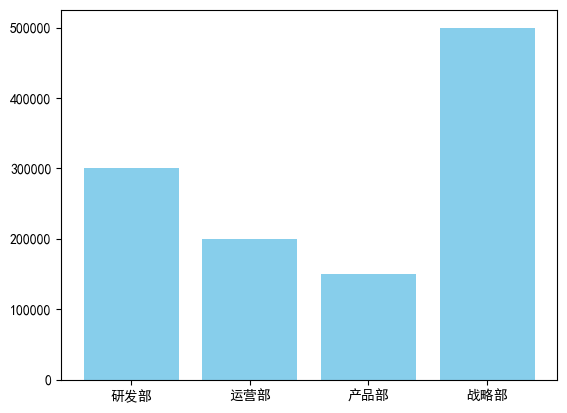

In [266]:
plt.bar(pdf['部门'],pdf['成本'],color='skyblue')
plt.show()

In [267]:
#我们还是以员工表为例,上面的图形只是为了引入
df.show(20)

+------+----+---+----+----------+----------+----+-------+---------+---------+----------+----------------+
|emp_id|姓名|age|性别|department|       job|city| salary|education|work_year|is_married|部门员工薪资排名|
+------+----+---+----+----------+----------+----+-------+---------+---------+----------+----------------+
|     2|刘芳| 32|  女|    产品部|  产品经理|上海|25000.0|     硕士|        7|        是|               1|
|   102|唐芳| 26|  女|    产品部|  产品经理|上海|24000.0|     硕士|        4|        否|               2|
|   192|庞芳| 29|  女|    产品部|  产品经理|上海|23500.0|     硕士|        5|        否|               3|
|   282|洪芳| 29|  女|    产品部|  产品经理|上海|23000.0|     硕士|        5|        否|               4|
|   148|卞芳| 33|  女|    产品部|  策略产品|重庆|20000.0|     硕士|        9|        是|               5|
|   238|岑芳| 33|  女|    产品部|  策略产品|重庆|19800.0|     硕士|        9|        是|               6|
|    58|毛芳| 28|  女|    产品部|  策略产品|重庆|19500.0|     硕士|        5|        否|               7|
|     8|郑敏| 31|  女|    产品部|  交互设计|重庆|16243.0|     硕士|    

In [268]:
#计算每个部门的平均薪资
df_agg=df.groupBy('department').agg(avg('salary').alias('薪资'))
df_pd=df_agg.toPandas()
df_pd.head()

,department,薪资
0,技术部,21067.516484
1,财务部,10935.000000
2,人事部,13505.038462
3,市场部,17380.469388
4,产品部,15805.634146


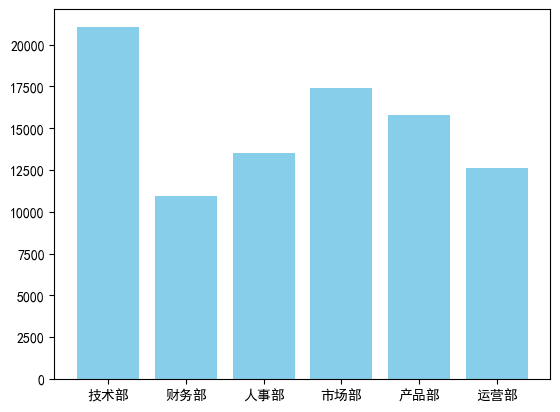

In [269]:
#通过柱状图📊来直观查看每个部门的平均薪资
plt.bar(df_pd['department'],df_pd['薪资'],color='skyblue')
plt.show()

In [279]:
from pyspark.sql.functions import expr, col
df.printSchema()
df.select("salary").show(10, truncate=False)
# 2. 筛选出salary为字符串类型的异常数据（关键！）
abnormal_data = df.filter(expr("typeof(salary) = 'string'"))
print("异常数据条数：", abnormal_data.count())
abnormal_data.show(truncate=False)  # 查看具体异常内容

root
 |-- emp_id: integer (nullable = true)
 |-- 姓名: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- 性别: string (nullable = true)
 |-- department: string (nullable = true)
 |-- job: string (nullable = true)
 |-- city: string (nullable = true)
 |-- salary: double (nullable = false)
 |-- education: string (nullable = true)
 |-- work_year: integer (nullable = true)
 |-- is_married: string (nullable = true)
 |-- 部门员工薪资排名: integer (nullable = false)

+-------+
|salary |
+-------+
|18500.0|
|25000.0|
|9800.0 |
|11200.0|
|22000.0|
|16243.0|
|16000.0|
|16243.0|
|10500.0|
|13000.0|
+-------+
only showing top 10 rows

异常数据条数： 0
+------+----+---+----+----------+---+----+------+---------+---------+----------+----------------+
|emp_id|姓名|age|性别|department|job|city|salary|education|work_year|is_married|部门员工薪资排名|
+------+----+---+----+----------+---+----+------+---------+---------+----------+----------------+
+------+----+---+----+----------+---+----+------+---------+---------+-----

In [281]:
print(type(sum))

<class 'builtin_function_or_method'>


In [283]:
from pyspark.sql.functions import sum
# 4:查看所有部门的薪资总和占比
df_agg=df.groupBy('department').agg(sum('salary').alias('总薪资'))
df_pd=df_agg.toPandas()
df_pd.head()


,department,总薪资
0,技术部,1917144.0
1,财务部,437400.0
2,人事部,351131.0
3,市场部,851643.0
4,产品部,648031.0


In [284]:
print(type(sum))

<class 'function'>


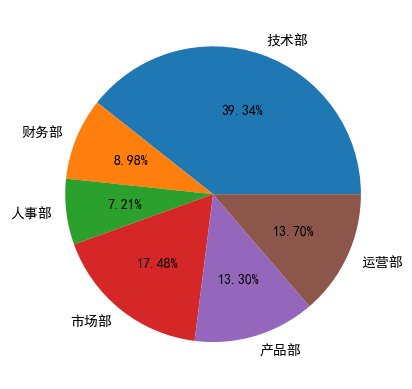

In [285]:
# autopct='%1.2f%%'表示显示到小数点后2位的百分比
plt.pie(df_pd['总薪资'],labels=df_pd['department'],autopct='%1.2f%%')
plt.show()


In [286]:
#查看整个公司的工资分布
df.show(20)

+------+----+---+----+----------+----------+----+-------+---------+---------+----------+----------------+
|emp_id|姓名|age|性别|department|       job|city| salary|education|work_year|is_married|部门员工薪资排名|
+------+----+---+----+----------+----------+----+-------+---------+---------+----------+----------------+
|     2|刘芳| 32|  女|    产品部|  产品经理|上海|25000.0|     硕士|        7|        是|               1|
|   102|唐芳| 26|  女|    产品部|  产品经理|上海|24000.0|     硕士|        4|        否|               2|
|   192|庞芳| 29|  女|    产品部|  产品经理|上海|23500.0|     硕士|        5|        否|               3|
|   282|洪芳| 29|  女|    产品部|  产品经理|上海|23000.0|     硕士|        5|        否|               4|
|   148|卞芳| 33|  女|    产品部|  策略产品|重庆|20000.0|     硕士|        9|        是|               5|
|   238|岑芳| 33|  女|    产品部|  策略产品|重庆|19800.0|     硕士|        9|        是|               6|
|    58|毛芳| 28|  女|    产品部|  策略产品|重庆|19500.0|     硕士|        5|        否|               7|
|     8|郑敏| 31|  女|    产品部|  交互设计|重庆|16243.0|     硕士|    

In [287]:
df_pd=df.select('salary').toPandas()
df_pd.head()

,salary
0,18500.0
1,25000.0
2,9800.0
3,11200.0
4,22000.0


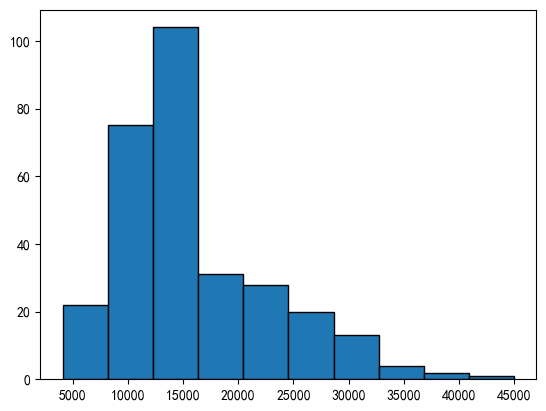

In [288]:
#直方图显示薪资的分布
plt.hist(df_pd['salary'],bins=10,edgecolor='black')
plt.show()

# PySpark写入和查询MySQL数据库？？？？？

In [289]:
spark.stop()